#katleen

#objetivo 
realizar un análisis estadísticos descriptivo del conjunto de datos de accidentes de tránsito utilizando medidas de tendencia central, gráficos de distrubucion, coeficiente de asimetría de Pearson, curtosis y puntacion Z.    

In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats 

In [10]:
# Leer el archivo de Excel 
df = pd.read_excel("../Datos/Accidentes de Transito - Dataset.xlsx")

# Mostrar las primeras 5 filas 
df.head()

,Unnamed: 0,Mes,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),MiBus,Metro
0,NaN,Enero,2017,2683,27.15,0.00,NaN,0,0.77,NaN,NaN
1,NaN,Febrero,2017,2606,27.35,18.50,NaN,0,0.75,NaN,NaN
2,NaN,Marzo,2017,3033,28.55,6.35,NaN,1,0.73,NaN,NaN
3,NaN,Abril,2017,2738,28.70,60.50,NaN,0,0.75,NaN,NaN
4,NaN,Mayo,2017,2972,27.85,228.95,NaN,0,0.75,NaN,NaN


In [11]:

import os 

os.getcwd()

'c:\\Users\\katle\\OneDrive\\DLA segundo semestres\\Documentos\\PROYECTO SEMESTRAL ST\\accidentes-transito-panama\\Notebooks'

In [12]:
os.listdir()

['Notebook_Diosa.ipynb', 'Notebook_Evan.ipynb', 'Notebook_Katleen.ipynb']

In [13]:
import os 

os.listdir("../Datos")

['Accidentes de Transito - Dataset.xlsx']

In [14]:
# Ver el tamaño del conjunto de datos 
df.shape

(92, 11)

In [15]:
# Ver los nombres de las columnas
df.columns


Index(['Unnamed: 0', 'Mes', 'Año', 'Accidentes',
       'Temperatura Prom. del Mes (°C)', 'Acum. Lluvia Diaria',
       'Días Hábiles del mes', 'Inicio de Clases',
       'Precio Gasolina (95 Octanos)', 'MiBus', 'Metro'],
      dtype='str')

In [16]:
# Información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      0 non-null      float64
 1   Mes                             92 non-null     str    
 2   Año                             92 non-null     int64  
 3   Accidentes                      92 non-null     int64  
 4   Temperatura Prom. del Mes (°C)  92 non-null     float64
 5   Acum. Lluvia Diaria             92 non-null     float64
 6   Días Hábiles del mes            0 non-null      float64
 7   Inicio de Clases                92 non-null     int64  
 8   Precio Gasolina (95 Octanos)    92 non-null     float64
 9   MiBus                           0 non-null      float64
 10  Metro                           0 non-null      float64
dtypes: float64(7), int64(3), str(1)
memory usage: 8.0 KB


In [17]:
# Eliminar la columna innecesaria
df = df.drop(columns=["Unnamed: 0"])

# Verificar las columnas nuevamente
df.columns

Index(['Mes', 'Año', 'Accidentes', 'Temperatura Prom. del Mes (°C)',
       'Acum. Lluvia Diaria', 'Días Hábiles del mes', 'Inicio de Clases',
       'Precio Gasolina (95 Octanos)', 'MiBus', 'Metro'],
      dtype='str')

In [18]:
# Seleccionar la variable que vamos a analizar 
variable = df["Accidentes"]

# Mostrar los primeros valores 
variable.head()

0    2683
1    2606
2    3033
3    2738
4    2972
Name: Accidentes, dtype: int64

In [19]:
# Calcular las medidas de tendencia central 

media = variable.mean()
mediana = variable.median()
moda = variable.mode()[0]

print(f"Mediana: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

Mediana: 2434.46
Mediana: 2431.5
Moda: 1967


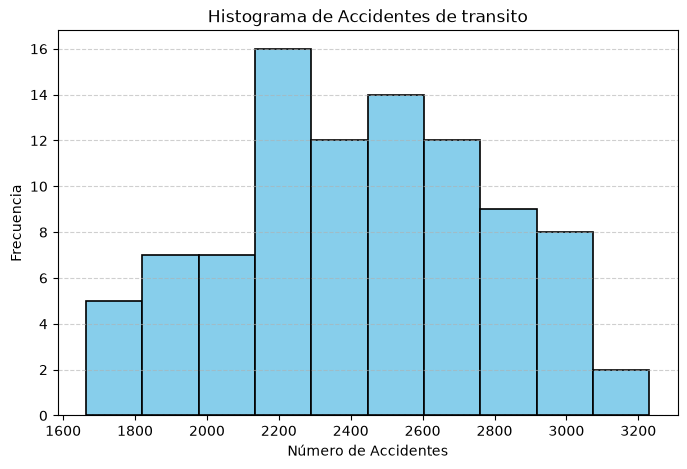

In [26]:
# Histograma de la variable Accidentes
plt.figure(figsize=(8,5))
plt.hist(variable, bins=10, edgecolor= 'black', linewidth=1.2, color="skyblue")
plt.title("Histograma de Accidentes de transito")
plt.xlabel("Número de Accidentes")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#El histograma muestra que la mayor concentración de meses presenta entre aproximadamente 2100 y 2700 accidentes. Se observan menos meses con valores muy bajos (cerca de 1700) o muy altos (por encima de 3000), lo que indica que la mayoría de los registros se agrupan en el centro de la distribución.#


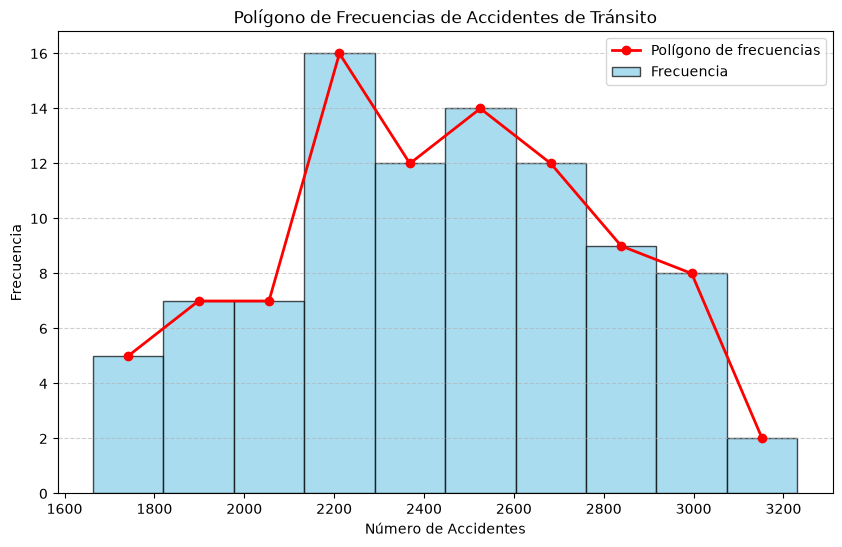

In [23]:
# Calcular frecuencia e intervalos
frecuencias, intervalos = np.histogram(variable, bins=10)
# Calcular los puntos medios 
puntos_medios = (intervalos[:-1]+ intervalos[1:]) /2
# Calcular el ancho de cada barra 
ancho_intervalo = intervalos[1] - intervalos[0]

# Poligono de frecuencias 
plt.figure(figsize=(10,6))
# Barras
plt.bar(
    puntos_medios,
    frecuencias,
    width=ancho_intervalo,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="Frecuencia"
)

# Polígono
plt.plot(
    puntos_medios,
    frecuencias,
    color="red",
    marker="o",
    linewidth=2,
    label="Polígono de frecuencias"
)

# Títulos
plt.title("Polígono de Frecuencias de Accidentes de Tránsito")
plt.xlabel("Número de Accidentes")
plt.ylabel("Frecuencia")

# Cuadrícula y leyenda
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()

plt.show()


#El polígono de frecuencias muestra que la mayor cantidad de observaciones se concentra en los intervalos centrales. La frecuencia disminuye hacia los extremos, indicando que los valores muy bajos y muy altos de accidentes son menos frecuentes.#


In [ ]:
# Calcular la desviacion estándar
#  